(chap-aihc-generative-models)=
# Generative Models for Healthcare Data: Fidelity, Utility, and Privacy Are Different Questions
**Content creators:** [Abhishek](https://github.com/moturuab)

Generative models learn a probability distribution and produce new samples rather than directly predicting an outcome. In healthcare, proposed uses include software testing, teaching, data augmentation, simulation, and privacy-aware data sharing. These uses sound similar but require different evidence. A dataset can match marginal histograms while destroying clinically important relationships; it can support one downstream task but fail another; and it can contain no exact duplicate yet still leak information.

This tutorial builds a deliberately imperfect ladder of tabular generators and evaluates their trade-offs. An optional extension applies a small convolutional variational autoencoder (VAE) to the **official PneumoniaMNIST** dataset.

## At a glance

| Item | What this tutorial uses |
|---|---|
| Source data | An intentionally simulated tabular cohort with nonlinear, noisy relationships |
| Weak generator | Independent feature-wise empirical marginals |
| Privacy anti-baseline | Label-stratified row resampling |
| Statistical generator | Label-conditional Gaussian mixture model (GMM) |
| Neural generator | Conditional variational autoencoder (CVAE) |
| Evaluation | Marginal fidelity, correlation, plausibility, downstream utility, exact copies, and nearest-neighbour proximity |
| Optional imaging | Official PneumoniaMNIST only; no invented fallback images |
| Runtime | About 30–35 minutes for the tabular core on CPU; optional image training benefits from one GPU |

:::{admonition} 30-minute core route
:class: tip
Complete Sections 1–5 to define the use and protected partitions, Sections 6–11 to build the four generators, and Sections 12–14 to compare fidelity, utility, and privacy warnings. That is the complete tabular lesson. Section 15 is a separate official PneumoniaMNIST extension; Sections 16–17 close with release governance and bounded conclusions.
:::

### Learning objectives

By the end, you should be able to:

1. explain the difference between resampling, density estimation, and neural generation;
2. distinguish reconstruction from generation;
3. evaluate fidelity, downstream utility, and privacy indicators separately;
4. recognize why exact-copy checks and nearest-neighbour distances are warnings, not privacy proofs;
5. explain why a more complex generator need not be better for every proposed use; and
6. write a bounded claim that matches the data and evaluation actually performed.

:::{admonition} Safety and interpretation
:class: danger
The tabular **source cohort itself is simulated**. Results can teach mechanics and expose failure modes, but they provide no evidence that any generator will preserve real clinical relationships or protect real patients. The optional image section uses a real public benchmark, yet remains an educational architecture demonstration—not a clinical synthesis or diagnostic study.
:::


## 1. Begin with the proposed use

“Generate synthetic patient data” is not a sufficiently specific goal. Before choosing a model, state who will receive the output, what they will do with it, what information the source contains, and what failure would cause harm.

| Proposed use | Main requirement | Example failure |
|---|---|---|
| Unit-test an analytics pipeline | Correct schema, ranges, and edge cases | Generated values never exercise rare or invalid states |
| Teach exploratory analysis | Plausible educational relationships, clear disclosure | Learners mistake authored patterns for epidemiology |
| Augment a classifier | Preserve task-relevant conditional structure | Synthetic rows reinforce spurious shortcuts or label errors |
| Share person-level records | Privacy under an explicit threat model | Membership or attribute information is inferred |
| Simulate operations | Preserve arrivals, delays, transitions, and interventions | Cross-sectional generator ignores workflow dynamics |

This notebook's bounded purpose is **method education**. We ask how four generator families differ on a known simulated distribution. We do not attempt a public data release, clinical augmentation study, or privacy certification.


## 2. A map of common generator families

The implemented ladder covers only a small part of the landscape.

| Family | Central idea | Strengths | Common limitations |
|---|---|---|---|
| Empirical resampling | Reuse observed rows | Simple; preserves observed joint combinations | Creates exact copies; cannot generate beyond observed support |
| Independent marginals | Sample each column separately | Very fast; often matches univariate histograms | Destroys correlations and conditional structure |
| Gaussian mixtures | Combine several multivariate Gaussian densities | Interpretable density model; fast sampling | Gaussian tails and component assumptions can be unrealistic |
| VAE/CVAE | Encode to a probabilistic latent space and decode samples | Smooth latent representation; flexible conditioning | Blurring/over-smoothing; optimization and prior mismatch |
| GAN | Train a generator against a discriminator | Can produce sharp complex samples | Training instability, mode collapse, difficult evaluation |
| Normalizing flow | Use invertible transformations with exact likelihood | Tractable density; reversible mapping | Architectural constraints and computational cost |
| Autoregressive model | Factorize a joint distribution into ordered conditionals | Explicit conditional probabilities | Ordering and sequential generation can be costly |
| Diffusion model | Learn to reverse a gradual noising process | Strong high-dimensional generation | Computationally intensive; memorization/privacy still require study |

No row in this table implies privacy. Privacy depends on the training procedure, access controls, release mechanism, adversary, and evaluation—not on calling data “synthetic.”


## 3. Why the source cohort is simulated

Real health records are sensitive and cannot normally be packaged in a public executable tutorial. Simulation lets us know which relationships *should* exist, deliberately add irreducible uncertainty, and observe which generators preserve or break them. It also avoids suggesting that a simple notebook provides an approved release process.

The limitations are fundamental. The source lacks real care pathways, treatment effects, documentation artefacts, coding changes, social context, rare conditions, repeated measurements, and privacy-bearing personal histories. Therefore, “fidelity to the source” below means fidelity to an authored mathematical distribution—not fidelity to patients.


In [1]:
# Reproducible setup ---------------------------------------------------------
# Scientific Python handles simulation/evaluation; PyTorch is used only for
# neural generators so their tensor operations remain visible.
SEED = 2026

import copy
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)


## 4. Construct a noisy, correlated source distribution

The source contains seven continuous features and a fictional 24-hour deterioration label. A hidden severity factor creates correlations among heart rate, blood pressure, oxygen saturation, creatinine, and lactate. The label is probabilistic and depends on both smooth effects and an interaction. Important determinants remain unmeasured, so downstream classifiers should achieve useful but far-from-perfect discrimination.

The values and coefficients are not clinical estimates. Bounds are chosen to make plots readable and to support explicit plausibility checks later.


In [2]:
n_source = 2600

# Latent severity creates dependence among the observed variables. Keeping it
# hidden ensures that downstream models do not receive the generator's answer.
severity = rng.normal(0, 1, n_source)
age = np.clip(rng.normal(64, 15, n_source), 18, 95)
heart_rate = np.clip(82 + 10 * severity + rng.normal(0, 12, n_source), 38, 165)
systolic_bp = np.clip(124 - 9 * severity + rng.normal(0, 15, n_source), 68, 205)
oxygen_sat = np.clip(96 - 1.5 * severity + rng.normal(0, 1.7, n_source), 82, 100)
creatinine = np.clip(np.exp(-0.05 + 0.24 * severity + 0.010 * (age - 60) + rng.normal(0, 0.34, n_source)), 0.3, 5.5)
lactate = np.clip(np.exp(-0.10 + 0.30 * severity + rng.normal(0, 0.42, n_source)), 0.3, 7.0)
respiratory_rate = np.clip(17 + 2.3 * severity + rng.normal(0, 3.2, n_source), 7, 38)

# The outcome is intentionally noisy. A threshold-like interaction gives
# nonlinear generators/classifiers something to preserve without making the
# task mechanically separable.
logit = (
    -2.65
    + 0.017 * (age - 60)
    + 0.028 * (heart_rate - 80)
    - 0.026 * (systolic_bp - 120)
    - 0.18 * (oxygen_sat - 95)
    + 0.32 * np.log1p(creatinine)
    + 0.38 * np.log1p(lactate)
    + 0.10 * (respiratory_rate - 17)
    + 0.48 * ((systolic_bp < 102) & (heart_rate > 102))
    + rng.normal(0, 0.95, n_source)  # unmeasured determinants
)
probability = 1 / (1 + np.exp(-logit))
outcome = rng.binomial(1, probability)

source = pd.DataFrame({
    "age": age,
    "heart_rate": heart_rate,
    "systolic_bp": systolic_bp,
    "oxygen_saturation": oxygen_sat,
    "creatinine": creatinine,
    "lactate": lactate,
    "respiratory_rate": respiratory_rate,
    "deterioration_24h": outcome,
})

print("Source shape:", source.shape)
print("Constructed outcome prevalence:", round(source["deterioration_24h"].mean(), 3))
source.describe(percentiles=[0.05, 0.5, 0.95]).T


Source shape: (2600, 8)
Constructed outcome prevalence: 0.166


,count,mean,std,min,5%,50%,95%,max
age,2600.0,64.261,14.798,18.000,39.546,64.888,88.725,95.000
heart_rate,2600.0,81.817,15.814,38.000,55.461,81.638,107.786,134.946
systolic_bp,2600.0,124.301,17.398,68.000,95.906,124.484,152.400,186.361
oxygen_saturation,2600.0,95.973,2.198,88.766,92.337,95.954,99.881,100.000
creatinine,2600.0,1.076,0.494,0.300,0.472,0.975,2.009,4.071
lactate,2600.0,1.033,0.563,0.300,0.389,0.905,2.093,4.866
respiratory_rate,2600.0,16.988,3.888,7.000,10.725,16.957,23.535,32.210
deterioration_24h,2600.0,0.166,0.372,0.000,0.000,0.000,1.000,1.000


**Reading the output.** The source has enough overlap that a model cannot infer the label perfectly. This is intentional: health outcomes depend on unmeasured biology, care, behaviour, measurement error, and chance. Near-perfect results on a small teaching dataset often indicate an overly easy construction, leakage, duplicates, or an evaluation mistake.

The descriptive table reports marginals only. It cannot show whether heart rate and blood pressure remain correlated, whether relationships differ by label, or whether rare combinations are represented.


## 5. Protect training, validation, and source-holdout partitions

We fit every generator on the source-training partition. The source-validation partition controls CVAE early stopping. The source-holdout partition is reserved for evaluation and never enters generator fitting, preprocessing, or early stopping.

This is not a privacy guarantee: holding out rows supports honest evaluation but does not protect the people in a real training dataset. We use the terms **source training**, **source validation**, and **source holdout** rather than “real data,” because all three partitions are simulated.


In [3]:
feature_columns = [
    "age", "heart_rate", "systolic_bp", "oxygen_saturation",
    "creatinine", "lactate", "respiratory_rate",
]
target_column = "deterioration_24h"

# First reserve 20% as an untouched source holdout. Then allocate 18.75% of the
# remaining rows to validation, yielding 65% train / 15% validation / 20% holdout.
source_development, source_holdout = train_test_split(
    source, test_size=0.20, stratify=source[target_column], random_state=SEED
)
source_train, source_validation = train_test_split(
    source_development,
    test_size=0.1875,
    stratify=source_development[target_column],
    random_state=SEED + 1,
)

# Scaling parameters are generator parameters too. They are fitted only on the
# source-training rows and reused unchanged for validation/holdout/generation.
feature_scaler = StandardScaler().fit(source_train[feature_columns])
X_train = feature_scaler.transform(source_train[feature_columns]).astype(np.float32)
X_validation = feature_scaler.transform(source_validation[feature_columns]).astype(np.float32)
X_holdout = feature_scaler.transform(source_holdout[feature_columns]).astype(np.float32)
y_train = source_train[target_column].to_numpy(dtype=np.int64)
y_validation = source_validation[target_column].to_numpy(dtype=np.int64)
y_holdout = source_holdout[target_column].to_numpy(dtype=np.int64)

pd.DataFrame({
    "rows": [len(source_train), len(source_validation), len(source_holdout)],
    "outcome_prevalence": [y_train.mean(), y_validation.mean(), y_holdout.mean()],
}, index=["source_train", "source_validation", "source_holdout"])


,rows,outcome_prevalence
source_train,1690,0.166
source_validation,390,0.167
source_holdout,520,0.165


## 6. Model A: independent empirical marginals—a deliberately weak generator

The weakest generator samples each feature independently from its source-training column. It can reproduce univariate histograms quite well, yet it destroys multivariable dependence. We also sample the label prevalence independently, so there is no relationship between generated features and generated outcomes.

This is useful as a negative control: a high marginal-fidelity score alone should not persuade us that a dataset is useful.


In [4]:
def generate_independent_marginals(n_rows, seed):
    '''Sample every feature and the label independently from training columns.'''
    local_rng = np.random.default_rng(seed)
    generated_features = np.column_stack([
        local_rng.choice(X_train[:, column_index], size=n_rows, replace=True)
        for column_index in range(X_train.shape[1])
    ]).astype(np.float32)
    generated_labels = local_rng.choice(y_train, size=n_rows, replace=True)
    return generated_features, generated_labels

independent_X, independent_y = generate_independent_marginals(len(source_train), SEED + 10)
print("Generated shape:", independent_X.shape)
print("Generated label prevalence:", round(independent_y.mean(), 3))


Generated shape: (1690, 7)
Generated label prevalence: 0.172


**Expected behaviour.** Each column should resemble its training marginal because values are sampled directly from that column. However, a high heart rate is no longer systematically associated with lower blood pressure or with the generated label. A model trained on these rows should have little downstream discrimination on the source holdout.


## 7. Model B: label-stratified resampling—a privacy anti-baseline

Resampling selects complete source-training rows with replacement within the requested label class. It preserves observed relationships and can produce strong downstream utility. But every generated row is an exact copy of a training row. Calling the output “synthetic” would not make a release safe.

We include this model because it exposes a crucial trade-off: the generator with excellent fidelity may be the clearest privacy failure.


In [5]:
def generate_by_resampling(requested_labels, seed):
    '''Copy complete scaled rows from the requested training label stratum.'''
    local_rng = np.random.default_rng(seed)
    generated = np.empty((len(requested_labels), X_train.shape[1]), dtype=np.float32)
    for label in [0, 1]:
        output_positions = np.flatnonzero(requested_labels == label)
        eligible_training_positions = np.flatnonzero(y_train == label)
        selected = local_rng.choice(eligible_training_positions, size=len(output_positions), replace=True)
        generated[output_positions] = X_train[selected]
    return generated, requested_labels.copy()

requested_labels = np.random.default_rng(SEED + 20).choice(y_train, size=len(source_train), replace=True)
resampled_X, resampled_y = generate_by_resampling(requested_labels, SEED + 21)
print("Unique generated rows:", np.unique(resampled_X, axis=0).shape[0], "of", len(resampled_X))


Unique generated rows: 1058 of 1690


## 8. Model C: label-conditional Gaussian mixtures

A Gaussian mixture represents each label class as a weighted collection of multivariate Gaussian components. Unlike independent marginals, its covariance matrices can preserve correlations. Unlike resampling, it produces continuous new combinations.

The assumptions are still restrictive. Gaussian components have unbounded tails, so generated oxygen saturation or age may fall outside a plausible range. Two components may underfit complex shapes, while too many components can fit idiosyncrasies. We choose the component count as a fixed teaching configuration rather than tuning it on the source holdout.


In [6]:
def fit_conditional_gmms(n_components=2):
    '''Fit one multivariate density to each label stratum using training rows only.'''
    models = {}
    for label in [0, 1]:
        models[label] = GaussianMixture(
            n_components=n_components,
            covariance_type="full",
            reg_covar=1e-4,
            n_init=5,
            random_state=SEED + label,
        ).fit(X_train[y_train == label])
    return models

def generate_from_gmms(models, requested_labels, seed):
    '''Draw new scaled rows from the density fitted to each requested class.'''
    generated = np.empty((len(requested_labels), X_train.shape[1]), dtype=np.float32)
    # GaussianMixture.sample uses its stored random_state. We clone and reseed
    # each model so this call is reproducible without mutating the fitted object.
    for label in [0, 1]:
        positions = np.flatnonzero(requested_labels == label)
        local_model = copy.deepcopy(models[label])
        local_model.random_state = seed + label
        # Numerical round-off can make an estimated covariance infinitesimally
        # asymmetric even after regularization. Sampling remains well defined,
        # so we suppress only NumPy's specific positive-semidefinite warning.
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="covariance is not symmetric positive-semidefinite",
                category=RuntimeWarning,
            )
            generated[positions] = local_model.sample(len(positions))[0].astype(np.float32)
    return generated, requested_labels.copy()

gmm_models = fit_conditional_gmms(n_components=2)
gmm_X, gmm_y = generate_from_gmms(gmm_models, requested_labels, SEED + 30)
print("GMM sample shape:", gmm_X.shape)


GMM sample shape: (1690, 7)


## 9. Model D: a conditional variational autoencoder

A CVAE learns a probabilistic latent representation $z$ of the feature vector $x$ while receiving the label condition $y$.

The encoder outputs a mean and log-variance for $q_\phi(z\mid x,y)$. During training, a latent sample is passed to the decoder, which reconstructs the features from $(z,y)$. The loss combines reconstruction error with a Kullback–Leibler (KL) term that encourages the latent distribution to remain close to a standard normal prior:

$$
\mathcal{L} = \underbrace{\lVert x-\hat{x}\rVert_2^2}_{\text{reconstruction}}
+ \beta\,\underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z\mid x,y)\,\|\,\mathcal{N}(0,I)\right)}_{\text{regularization}}.
$$

If $\beta$ is too small, reconstruction may be good but samples from the prior can be poor. If it is too large, the latent code may carry too little information. The architecture and $\beta$ below are compact teaching choices, not optimized clinical settings.


In [7]:
class ConditionalVAE(nn.Module):
    '''Small fully connected CVAE for seven scaled continuous features.'''
    def __init__(self, n_features, n_conditions=2, latent_dim=4):
        super().__init__()
        self.n_conditions = n_conditions
        self.latent_dim = latent_dim

        # The condition is one-hot encoded and concatenated to both the encoder
        # input and decoder input so generation can request a label stratum.
        self.encoder = nn.Sequential(
            nn.Linear(n_features + n_conditions, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.mean = nn.Linear(16, latent_dim)
        self.log_variance = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_conditions, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, n_features),
        )

    def condition_vector(self, labels):
        return torch.nn.functional.one_hot(labels.long(), self.n_conditions).float()

    def encode(self, features, labels):
        hidden = self.encoder(torch.cat([features, self.condition_vector(labels)], dim=1))
        return self.mean(hidden), self.log_variance(hidden)

    @staticmethod
    def reparameterize(mean, log_variance):
        # Reparameterization keeps the random draw differentiable with respect
        # to the encoder parameters during backpropagation.
        standard_deviation = torch.exp(0.5 * log_variance)
        noise = torch.randn_like(standard_deviation)
        return mean + noise * standard_deviation

    def decode(self, latent, labels):
        return self.decoder(torch.cat([latent, self.condition_vector(labels)], dim=1))

    def forward(self, features, labels):
        mean, log_variance = self.encode(features, labels)
        latent = self.reparameterize(mean, log_variance)
        reconstruction = self.decode(latent, labels)
        return reconstruction, mean, log_variance


def cvae_loss(reconstruction, original, mean, log_variance, beta=0.04):
    '''Return total, reconstruction, and KL losses averaged over a batch.'''
    reconstruction_loss = torch.mean((reconstruction - original) ** 2)
    kl_loss = -0.5 * torch.mean(1 + log_variance - mean.pow(2) - log_variance.exp())
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cvae = ConditionalVAE(n_features=len(feature_columns), latent_dim=4).to(device)
print(cvae)
print("Training device:", device)


ConditionalVAE(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (mean): Linear(in_features=16, out_features=4, bias=True)
  (log_variance): Linear(in_features=16, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Training device: cpu


## 10. Train with validation-based early stopping

The CVAE fits source-training rows only. At the end of each epoch, we calculate the same loss on the source-validation rows without gradient updates. We save the best validation state and stop after 12 epochs without meaningful improvement.

Early stopping limits overfitting to this training sample, but it is not a privacy mechanism. The loss also does not directly measure whether important tails, correlations, subgroups, or downstream tasks are preserved.


Stopped after 147 epochs; best validation loss = 0.2845


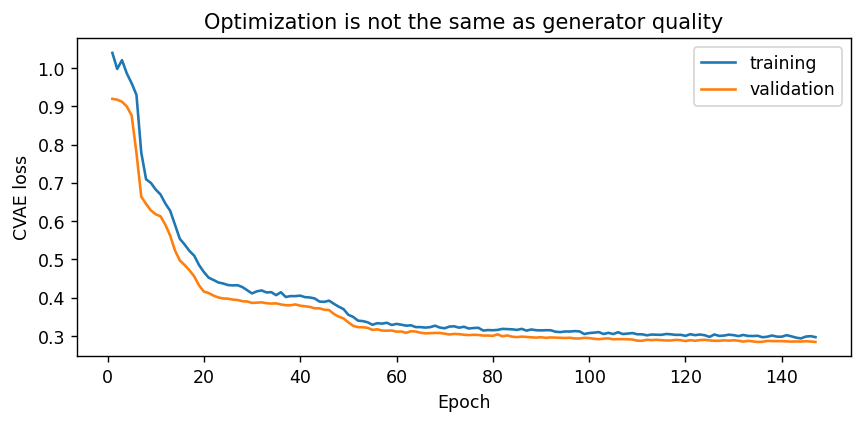

In [8]:
# Phase 1: create shuffled training batches and fixed validation tensors. Only
# batches from the training loader participate in gradient updates.
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=128,
    shuffle=True,
)
validation_features = torch.tensor(X_validation, device=device)
validation_labels = torch.tensor(y_validation, device=device)

optimizer = torch.optim.AdamW(cvae.parameters(), lr=1e-3, weight_decay=1e-4)
# Phase 2: retain the best validation state rather than the final epoch.
best_state = None
best_validation_loss = np.inf
patience_left = 12
history = []

for epoch in range(1, 151):
    cvae.train()
    batch_losses = []

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        reconstruction, mean, log_variance = cvae(batch_features, batch_labels)
        loss, reconstruction_loss, kl_loss = cvae_loss(
            reconstruction, batch_features, mean, log_variance
        )
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Evaluation mode and no_grad() prevent parameter updates and reduce memory.
    cvae.eval()
    with torch.no_grad():
        val_reconstruction, val_mean, val_log_variance = cvae(validation_features, validation_labels)
        val_loss, _, _ = cvae_loss(
            val_reconstruction, validation_features, val_mean, val_log_variance
        )

    mean_train_loss = float(np.mean(batch_losses))
    mean_val_loss = float(val_loss.item())
    history.append({"epoch": epoch, "train_loss": mean_train_loss, "validation_loss": mean_val_loss})

    if mean_val_loss < best_validation_loss - 1e-4:
        best_validation_loss = mean_val_loss
        best_state = copy.deepcopy(cvae.state_dict())
        patience_left = 12
    else:
        patience_left -= 1
        if patience_left == 0:
            break

# Phase 3: restore the selected state so later generation uses the configuration
# chosen without consulting the source holdout.
cvae.load_state_dict(best_state)
history_frame = pd.DataFrame(history)
print(f"Stopped after {len(history_frame)} epochs; best validation loss = {best_validation_loss:.4f}")

plt.figure(figsize=(7, 3.5))
plt.plot(history_frame["epoch"], history_frame["train_loss"], label="training")
plt.plot(history_frame["epoch"], history_frame["validation_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("CVAE loss")
plt.title("Optimization is not the same as generator quality")
plt.legend()
plt.tight_layout()
plt.show()


**How to read the curves.** Falling training loss shows that the network is optimizing its objective. Validation loss estimates reconstruction/regularization on unseen source-simulated rows. Neither curve establishes distributional fidelity, useful augmentation, privacy, fairness, or clinical value. Those are separate evaluation questions.


## 11. Separate reconstruction from generation

Reconstruction begins with a source row, encodes it, and decodes an approximation. Generation begins with a new latent sample from the prior and a requested condition. A VAE can reconstruct reasonably while generating poorly if its encoded latent distribution does not match the sampling prior.


In [9]:
def generate_from_cvae(model, requested_labels, seed):
    '''Sample latent codes from N(0, I), then decode under requested labels.'''
    torch.manual_seed(seed)
    labels_tensor = torch.tensor(requested_labels, dtype=torch.long, device=device)
    latent = torch.randn(len(requested_labels), model.latent_dim, device=device)
    model.eval()
    with torch.no_grad():
        generated = model.decode(latent, labels_tensor).cpu().numpy().astype(np.float32)
    return generated, requested_labels.copy()

cvae_X, cvae_y = generate_from_cvae(cvae, requested_labels, SEED + 40)

# Show reconstruction error by feature on the protected source-validation set.
cvae.eval()
with torch.no_grad():
    reconstruction, _, _ = cvae(validation_features, validation_labels)
reconstruction = reconstruction.cpu().numpy()
reconstruction_rmse = np.sqrt(np.mean((reconstruction - X_validation) ** 2, axis=0))

pd.Series(reconstruction_rmse, index=feature_columns, name="scaled validation reconstruction RMSE")


age                  0.394
heart_rate           0.647
systolic_bp          0.329
oxygen_saturation    0.503
creatinine           0.461
lactate              0.366
respiratory_rate     0.464
Name: scaled validation reconstruction RMSE, dtype: float32

**Interpretation.** Reconstruction error identifies features the compressed latent representation reproduces more or less accurately. It is not a clinical error rate. Generation will be assessed on collections of new rows, not by pairing each generated row with a patient.


## 12. Use one scorecard for every generator

We now compare the same properties for each model.

- **Mean KS statistic:** average maximum gap between generated and source-holdout empirical cumulative distributions; lower is better for marginals.
- **Correlation RMSE:** difference between generated and holdout correlation matrices; lower is better for linear dependence.
- **Plausibility violations:** fraction of generated rows outside broad authored bounds; lower is better, but passing bounds does not imply clinical plausibility.
- **TSTR utility:** train a logistic classifier on generated rows, then test it on the untouched source holdout; higher AUROC/AUPRC is better for this one task. Because generation is stochastic, we report the mean and standard deviation across 40 independently seeded generated training sets.
- **Exact-copy fraction:** fraction of generated rows identical to a source-training row in scaled feature space; high values are a clear warning.
- **Median nearest-neighbour distance:** typical scaled distance to the closest source-training row; zero is concerning, but a nonzero value is not a privacy guarantee.

Metrics can conflict because they answer different questions. Fidelity and proximity use one labelled representative draw for inspectability; TSTR is repeated to prevent one lucky or unlucky synthetic draw from driving the lesson. We do not collapse the columns into one “synthetic data quality” score.


In [10]:
# Broad plausibility bounds in original units. They reflect the constructed
# teaching support, not clinical reference ranges or release rules.
plausibility_bounds = {
    "age": (18, 100),
    "heart_rate": (30, 220),
    "systolic_bp": (55, 240),
    "oxygen_saturation": (70, 100),
    "creatinine": (0.1, 10),
    "lactate": (0.1, 15),
    "respiratory_rate": (4, 55),
}

def evaluate_generator(name, generated_X, generated_y, utility_replicates):
    '''Evaluate fidelity, one utility task, and simple privacy warning signals.'''
    # Marginal fidelity: compare each generated scaled feature to the protected
    # source holdout. No generator saw the holdout during fitting.
    mean_ks = np.mean([
        ks_2samp(generated_X[:, j], X_holdout[:, j]).statistic
        for j in range(generated_X.shape[1])
    ])

    # Correlation differences expose the failure of independent marginals.
    generated_correlation = np.corrcoef(generated_X, rowvar=False)
    holdout_correlation = np.corrcoef(X_holdout, rowvar=False)
    correlation_rmse = np.sqrt(np.mean((generated_correlation - holdout_correlation) ** 2))

    # Inverse-transform only for human-readable plausibility rules.
    generated_original_units = feature_scaler.inverse_transform(generated_X)
    violation_matrix = np.column_stack([
        (generated_original_units[:, j] < plausibility_bounds[column][0])
        | (generated_original_units[:, j] > plausibility_bounds[column][1])
        for j, column in enumerate(feature_columns)
    ])
    violation_fraction = violation_matrix.any(axis=1).mean()

    # TSTR: refit the same linear downstream model on several independently
    # generated training sets. Repetition makes a chance-level generator less
    # likely to look useful because of one accidental finite-sample correlation.
    tstr_rows = []
    for replicate_X, replicate_y in utility_replicates:
        downstream = LogisticRegression(max_iter=2000, random_state=SEED).fit(
            replicate_X, replicate_y
        )
        holdout_probability = downstream.predict_proba(X_holdout)[:, 1]
        tstr_rows.append({
            "AUROC": roc_auc_score(y_holdout, holdout_probability),
            "AUPRC": average_precision_score(y_holdout, holdout_probability),
        })
    tstr_frame = pd.DataFrame(tstr_rows)

    # Nearest-neighbour distance is computed in training-standardized space so
    # features with larger numeric units do not dominate Euclidean distance.
    neighbour_model = NearestNeighbors(n_neighbors=1).fit(X_train)
    nearest_distance = neighbour_model.kneighbors(generated_X, return_distance=True)[0][:, 0]

    # Exact equality is meaningful for the resampling baseline because those
    # rows are literal float32 copies. It will be rare for continuous generators.
    training_row_bytes = {row.tobytes() for row in np.ascontiguousarray(X_train)}
    exact_copy_fraction = np.mean([row.tobytes() in training_row_bytes for row in np.ascontiguousarray(generated_X)])

    return {
        "generator": name,
        "mean_KS (lower)": mean_ks,
        "correlation_RMSE (lower)": correlation_rmse,
        "plausibility_violation_fraction": violation_fraction,
        "TSTR_AUROC_mean": tstr_frame["AUROC"].mean(),
        "TSTR_AUROC_SD": tstr_frame["AUROC"].std(ddof=1),
        "TSTR_AUPRC_mean": tstr_frame["AUPRC"].mean(),
        "TSTR_AUPRC_SD": tstr_frame["AUPRC"].std(ddof=1),
        "exact_copy_fraction": exact_copy_fraction,
        "median_nearest_distance": np.median(nearest_distance),
    }


generated_sets = {
    "Independent marginals": (independent_X, independent_y),
    "Stratified resampling": (resampled_X, resampled_y),
    "Conditional GMM": (gmm_X, gmm_y),
    "Conditional VAE": (cvae_X, cvae_y),
}


def generate_utility_replicates(generator_name, n_repeats=40):
    '''Generate repeated synthetic training sets without touching the holdout.'''
    replicates = []
    for repeat in range(n_repeats):
        repeat_seed = SEED + 1_000 + 20 * repeat

        if generator_name == "Independent marginals":
            replicate = generate_independent_marginals(len(source_train), repeat_seed)
        else:
            # Conditional generators receive labels drawn from training
            # prevalence. The holdout labels never determine generation.
            labels = np.random.default_rng(repeat_seed).choice(
                y_train, size=len(source_train), replace=True
            )
            if generator_name == "Stratified resampling":
                replicate = generate_by_resampling(labels, repeat_seed + 1)
            elif generator_name == "Conditional GMM":
                replicate = generate_from_gmms(gmm_models, labels, repeat_seed + 1)
            elif generator_name == "Conditional VAE":
                replicate = generate_from_cvae(cvae, labels, repeat_seed + 1)
            else:
                raise ValueError(f"Unknown generator: {generator_name}")
        replicates.append(replicate)
    return replicates


scorecard = pd.DataFrame([
    evaluate_generator(
        name, generated_X, generated_y,
        generate_utility_replicates(name, n_repeats=40),
    )
    for name, (generated_X, generated_y) in generated_sets.items()
]).set_index("generator")

# Add a source-training utility reference. It is not a generator and therefore
# has no fidelity/privacy-warning values in this table.
source_downstream = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_train, y_train)
source_probability = source_downstream.predict_proba(X_holdout)[:, 1]
scorecard.loc["Source-training reference", ["TSTR_AUROC_mean", "TSTR_AUPRC_mean"]] = [
    roc_auc_score(y_holdout, source_probability),
    average_precision_score(y_holdout, source_probability),
]

print(
    "No-skill references: AUROC = 0.500; "
    f"AUPRC = source-holdout prevalence = {y_holdout.mean():.3f}"
)
scorecard


No-skill references: AUROC = 0.500; AUPRC = source-holdout prevalence = 0.165


,mean_KS (lower),correlation_RMSE (lower),plausibility_violation_fraction,TSTR_AUROC_mean,TSTR_AUROC_SD,TSTR_AUPRC_mean,TSTR_AUPRC_SD,exact_copy_fraction,median_nearest_distance
generator,,,,,,,,,
Independent marginals,0.040,0.268,0.000,0.476,0.142,0.192,0.080,0.0,1.009
Stratified resampling,0.040,0.040,0.000,0.776,0.004,0.416,0.008,1.0,0.000
Conditional GMM,0.053,0.046,0.060,0.776,0.004,0.417,0.007,0.0,0.913
Conditional VAE,0.104,0.174,0.014,0.660,0.015,0.303,0.012,0.0,0.774
Source-training reference,NaN,NaN,NaN,0.780,NaN,0.422,NaN,NaN,NaN


:::{admonition} How to interpret the scorecard
:class: important
- **Independent marginals** can look reasonable on univariate KS values while losing correlation and yielding chance-like average task utility. The reported standard deviation shows why one stochastic draw should not carry the conclusion.
- **Resampling** should preserve useful relationships, but its exact-copy fraction reveals that it is not meaningful synthesis for sharing.
- **Conditional GMM** may offer useful task structure and correlations while creating tail violations because Gaussian components are unbounded.
- **CVAE** may avoid exact copies but smooth distributions, weaken correlations, or underperform the simpler GMM on this small tabular problem.

No model is expected to dominate every column. The source-training row is a comparator for the same downstream logistic model, not a performance ceiling: generation, denoising, regularization, or ordinary sampling variation can sometimes place a synthetic-trained estimate above it. None of the privacy-warning columns is a formal privacy assessment.

**Stored-run interpretation.** Across 40 generated training sets, independent marginals produce mean AUROC near chance (**0.476 ± 0.142**) and weak AUPRC (**0.192 ± 0.080**) despite good marginal KS, because the labels and features were generated independently. Resampling and the conditional GMM both reach mean AUROC about **0.776**, close to the **0.780** source-training comparator; however, resampling has an exact-copy fraction of **1.00**, while the GMM has no exact copies but places **6.0%** of rows outside the broad authored bounds. The CVAE avoids exact copies yet reaches only **0.660 ± 0.015** AUROC and has worse correlation error than the GMM. This is the intended lesson: complexity does not create a universal winner, and high utility can coexist with an unacceptable privacy warning.
:::


## 13. Make the trade-offs visible

Tables support precise comparison, while plots reveal where aggregate metrics hide problems. We compare two feature distributions, one clinically intuitive correlation, downstream utility, and nearest-neighbour proximity.


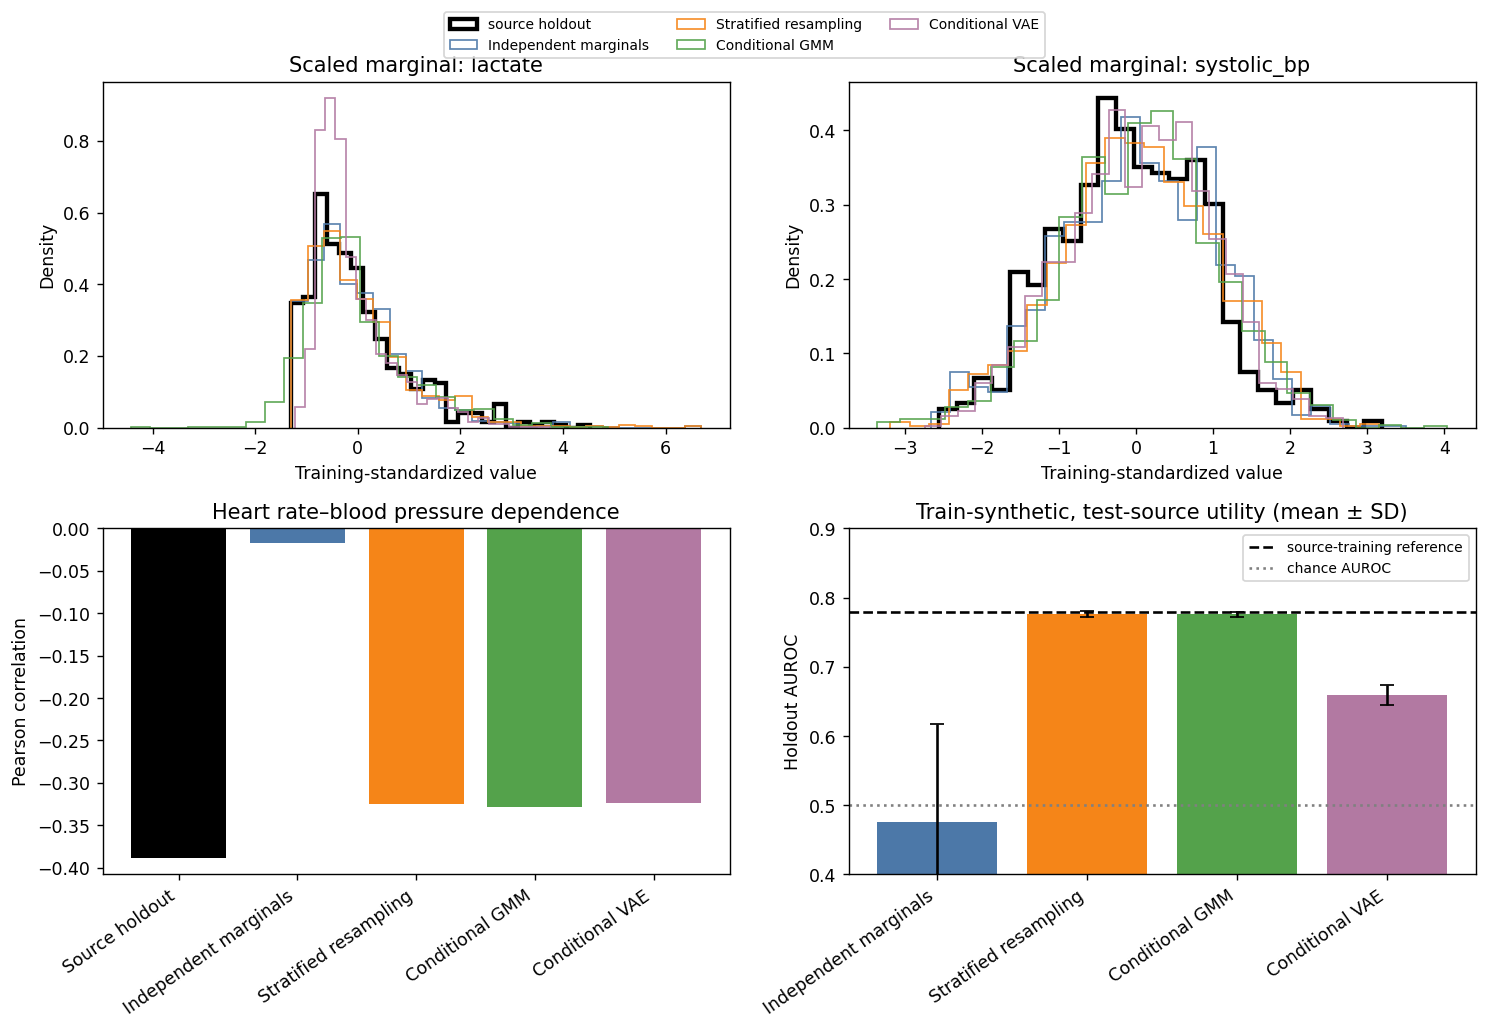

In [11]:
# Phase 1: reuse one colour per generator across panels to keep the comparison
# traceable from fidelity to utility.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = {
    "Independent marginals": "#4C78A8",
    "Stratified resampling": "#F58518",
    "Conditional GMM": "#54A24B",
    "Conditional VAE": "#B279A2",
}

feature_indices = {name: feature_columns.index(name) for name in ["lactate", "systolic_bp"]}
# Phase 2: inspect marginals first, recognizing that these plots cannot reveal
# whether conditional or cross-feature relationships were retained.
for ax, feature_name in zip(axes[0], ["lactate", "systolic_bp"]):
    j = feature_indices[feature_name]
    ax.hist(X_holdout[:, j], bins=25, density=True, histtype="step", linewidth=2.5, color="black", label="source holdout")
    for generator_name, (generated_X, _) in generated_sets.items():
        ax.hist(generated_X[:, j], bins=25, density=True, histtype="step", alpha=0.9, color=colors[generator_name], label=generator_name)
    ax.set_title(f"Scaled marginal: {feature_name}")
    ax.set_xlabel("Training-standardized value")
    ax.set_ylabel("Density")

# Correlation structure. Independent marginals should lose this relationship.
hr_index = feature_columns.index("heart_rate")
bp_index = feature_columns.index("systolic_bp")
correlation_values = {"Source holdout": np.corrcoef(X_holdout[:, hr_index], X_holdout[:, bp_index])[0, 1]}
for generator_name, (generated_X, _) in generated_sets.items():
    correlation_values[generator_name] = np.corrcoef(generated_X[:, hr_index], generated_X[:, bp_index])[0, 1]
axes[1, 0].bar(range(len(correlation_values)), correlation_values.values(), color=["black"] + list(colors.values()))
axes[1, 0].set_xticks(range(len(correlation_values)), correlation_values.keys(), rotation=35, ha="right")
axes[1, 0].set_ylabel("Pearson correlation")
axes[1, 0].set_title("Heart rate–blood pressure dependence")

utility_rows = scorecard.drop(index="Source-training reference")
# Phase 3: compare task utility with both chance and the source-training
# reference; do not collapse the panels into one synthetic-quality score.
axes[1, 1].bar(
    range(len(utility_rows)), utility_rows["TSTR_AUROC_mean"],
    yerr=utility_rows["TSTR_AUROC_SD"], capsize=4,
    color=list(colors.values()),
)
axes[1, 1].axhline(
    scorecard.loc["Source-training reference", "TSTR_AUROC_mean"],
    color="black", linestyle="--", label="source-training reference",
)
axes[1, 1].axhline(0.5, color="0.5", linestyle=":", label="chance AUROC")
axes[1, 1].set_xticks(range(len(utility_rows)), utility_rows.index, rotation=35, ha="right")
axes[1, 1].set_ylim(0.4, 0.9)
axes[1, 1].set_ylabel("Holdout AUROC")
axes[1, 1].set_title("Train-synthetic, test-source utility (mean ± SD)")
axes[1, 1].legend(fontsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03), fontsize=8)
plt.tight_layout()
plt.show()


**How to read the figure.** Similar marginal curves can coexist with a missing correlation and poor downstream utility. Conversely, good TSTR performance on one label does not prove that the dataset supports descriptive research, another outcome, subgroup analysis, or tail-risk estimation. Resampling's utility may be strong precisely because it reuses source rows.


## 14. Privacy requires a threat model, not a distance threshold

Exact copies are an obvious red flag, and unusually small distances to training rows can motivate investigation. But distance depends on scaling, feature selection, dimensionality, mixed data types, and the underlying population. A generated record can be far from every source row yet still reveal whether a person was in training, expose a rare attribute, or enable singling out when combined with other information.

A defensible privacy evaluation begins with the release scenario:

- Who receives row-level data, through what environment, and with what controls?
- What auxiliary information might an attacker possess?
- Are the relevant attacks membership inference, attribute inference, singling out, linkage, or model extraction?
- What utility must be retained, and for which groups and rare events?
- Is a formal mechanism such as differential privacy required, and how is its budget governed?

The nearest-neighbour and exact-copy columns in this notebook are **screening indicators only**. They are not evidence of anonymization or compliance with any privacy law.


:::{admonition} Tabular core route complete
:class: tip
You have now compared four generators under one fidelity–utility–privacy scorecard and defined why none of those columns certifies a release. Continue to Section 15 for the separate official-image extension, or move to Section 16 for the governance checklist.
:::

## 15. Optional imaging extension: official PneumoniaMNIST only

PneumoniaMNIST is a MedMNIST binary classification benchmark derived from pediatric chest radiographs. It contains 5,856 images at $28\times28$ pixels with official splits of 4,708 training, 524 validation, and 624 test images. In this extension, labels are not used for diagnosis; we demonstrate how a convolutional VAE preserves spatial structure when reconstructing and sampling small images.

There is deliberately **no synthetic fallback**. If the official archive cannot be downloaded, the cell stops. Replacing it with generated shapes would change the data modality and could mislead learners.

:::{admonition} Imaging scope
:class: warning
PneumoniaMNIST is heavily downsampled and designed for lightweight education/benchmarking. A short VAE run does not establish radiographic realism, pathology preservation, diversity, privacy, usefulness for classifier augmentation, or safety. Generated images must not be interpreted as patient cases.
:::


In [12]:
# Run once in a fresh Colab runtime with internet access. Pin the lightweight
# dataset wrapper so split metadata and loader behaviour remain reproducible.
%pip install -q "medmnist==3.0.2" "torch>=2.0" "torchvision>=0.15"


In [13]:
from pathlib import Path
import warnings

# We provide an explicit writable cache below. Suppress only MedMNIST's
# import-time warning about its optional default root in locked-down runtimes.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Failed to setup default root")
    from medmnist import INFO, PneumoniaMNIST

image_root = Path("data/medmnist")
image_root.mkdir(parents=True, exist_ok=True)

# Use the official partitions exactly as distributed. Download failures are
# surfaced rather than replaced with a different or invented dataset.
pneumonia_train = PneumoniaMNIST(split="train", root=str(image_root), download=True)
pneumonia_val = PneumoniaMNIST(split="val", root=str(image_root), download=True)
pneumonia_test = PneumoniaMNIST(split="test", root=str(image_root), download=True)

assert len(pneumonia_train) == 4708
assert len(pneumonia_val) == 524
assert len(pneumonia_test) == 624

pneumonia_info = INFO["pneumoniamnist"]
print("Official splits:", {"train": len(pneumonia_train), "validation": len(pneumonia_val), "test": len(pneumonia_test)})
print("Task:", pneumonia_info["task"], "Labels:", pneumonia_info["label"])


Official splits: {'train': 4708, 'validation': 524, 'test': 624}
Task: binary-class Labels: {'0': 'normal', '1': 'pneumonia'}


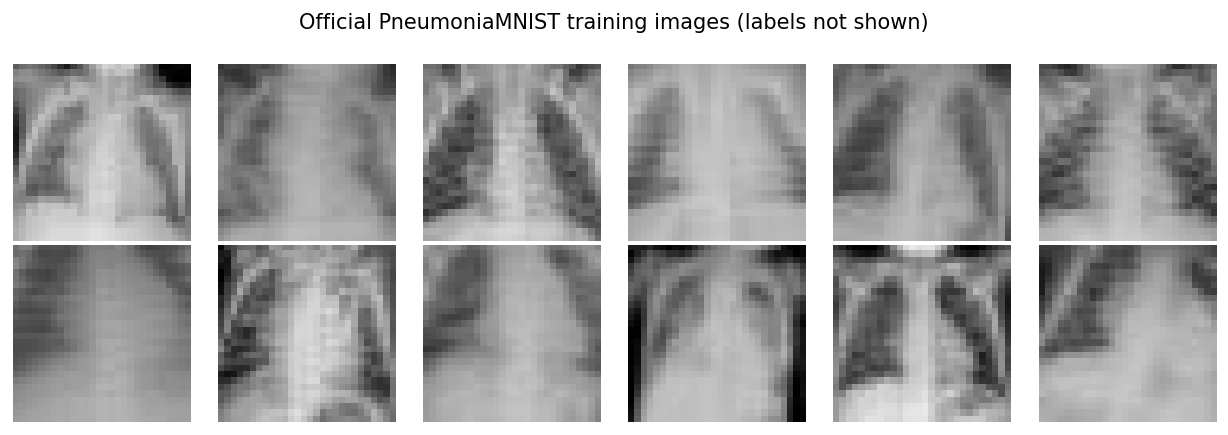

In [14]:
def image_dataset_to_tensor(dataset):
    '''Convert official PIL images to float tensors shaped [N, 1, 28, 28].'''
    array = np.stack([np.asarray(dataset[i][0], dtype=np.float32) for i in range(len(dataset))])
    return torch.tensor(array[:, None] / 255.0, dtype=torch.float32)

image_train_tensor = image_dataset_to_tensor(pneumonia_train)
image_val_tensor = image_dataset_to_tensor(pneumonia_val)

fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for ax, index in zip(axes.ravel(), np.linspace(0, len(image_train_tensor) - 1, 12, dtype=int)):
    ax.imshow(image_train_tensor[index, 0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Official PneumoniaMNIST training images (labels not shown)")
plt.tight_layout()
plt.show()


### A tiny convolutional VAE

The encoder reduces a $1\times28\times28$ image to a latent distribution. The decoder maps a latent sample back to the image grid. We use binary cross-entropy reconstruction loss because pixels are scaled to $[0,1]$, plus a small KL term. To keep the extension practical on CPU, we train for only three epochs and restore the epoch with the best validation loss. The test split is intentionally not used in this architecture demonstration.


In [15]:
class TinyConvVAE(nn.Module):
    '''Compact convolutional VAE for 28×28 one-channel images.'''
    def __init__(self, latent_dim=12):
        super().__init__()
        self.latent_dim = latent_dim
        # Phase 1: strided convolutions compress 28×28 -> 14×14 -> 7×7 while
        # increasing channel capacity.
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
            nn.Flatten(),
        )
        self.mean = nn.Linear(32 * 7 * 7, latent_dim)
        self.log_variance = nn.Linear(32 * 7 * 7, latent_dim)
        # Phase 2: transpose convolutions mirror the encoder and a sigmoid bounds
        # reconstructed intensities to the same [0, 1] scale as the inputs.
        self.decoder_input = nn.Linear(latent_dim, 32 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, images):
        hidden = self.encoder(images)
        return self.mean(hidden), self.log_variance(hidden)

    def decode(self, latent):
        return self.decoder(self.decoder_input(latent))

    def forward(self, images):
        mean, log_variance = self.encode(images)
        latent = ConditionalVAE.reparameterize(mean, log_variance)
        return self.decode(latent), mean, log_variance


def image_vae_loss(reconstruction, original, mean, log_variance, beta=0.002):
    reconstruction_loss = torch.nn.functional.binary_cross_entropy(reconstruction, original)
    kl_loss = -0.5 * torch.mean(1 + log_variance - mean.pow(2) - log_variance.exp())
    return reconstruction_loss + beta * kl_loss


image_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_model = TinyConvVAE(latent_dim=12).to(image_device)
image_optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)
image_loader = DataLoader(TensorDataset(image_train_tensor), batch_size=128, shuffle=True)

# Phase 3: use official validation images for stopping only; the published test
# partition is not opened in this optional architecture demonstration.
best_image_state, best_image_val, patience_left = None, np.inf, 3
image_history = []
for epoch in range(1, 4):
    image_model.train()
    training_losses = []
    for (batch_images,) in image_loader:
        batch_images = batch_images.to(image_device)
        image_optimizer.zero_grad()
        reconstruction, mean, log_variance = image_model(batch_images)
        loss = image_vae_loss(reconstruction, batch_images, mean, log_variance)
        loss.backward()
        image_optimizer.step()
        training_losses.append(loss.item())

    image_model.eval()
    with torch.no_grad():
        val_images = image_val_tensor.to(image_device)
        val_reconstruction, val_mean, val_log_variance = image_model(val_images)
        validation_loss = image_vae_loss(val_reconstruction, val_images, val_mean, val_log_variance).item()
    image_history.append({"epoch": epoch, "train_loss": np.mean(training_losses), "validation_loss": validation_loss})

    if validation_loss < best_image_val - 1e-4:
        best_image_val = validation_loss
        best_image_state = copy.deepcopy(image_model.state_dict())
        patience_left = 3
    else:
        patience_left -= 1
        if patience_left == 0:
            break

# Restore the validation-selected weights before visualization.
image_model.load_state_dict(best_image_state)
pd.DataFrame(image_history)


,epoch,train_loss,validation_loss
0,1,0.672,0.661
1,2,0.652,0.648
2,3,0.645,0.644


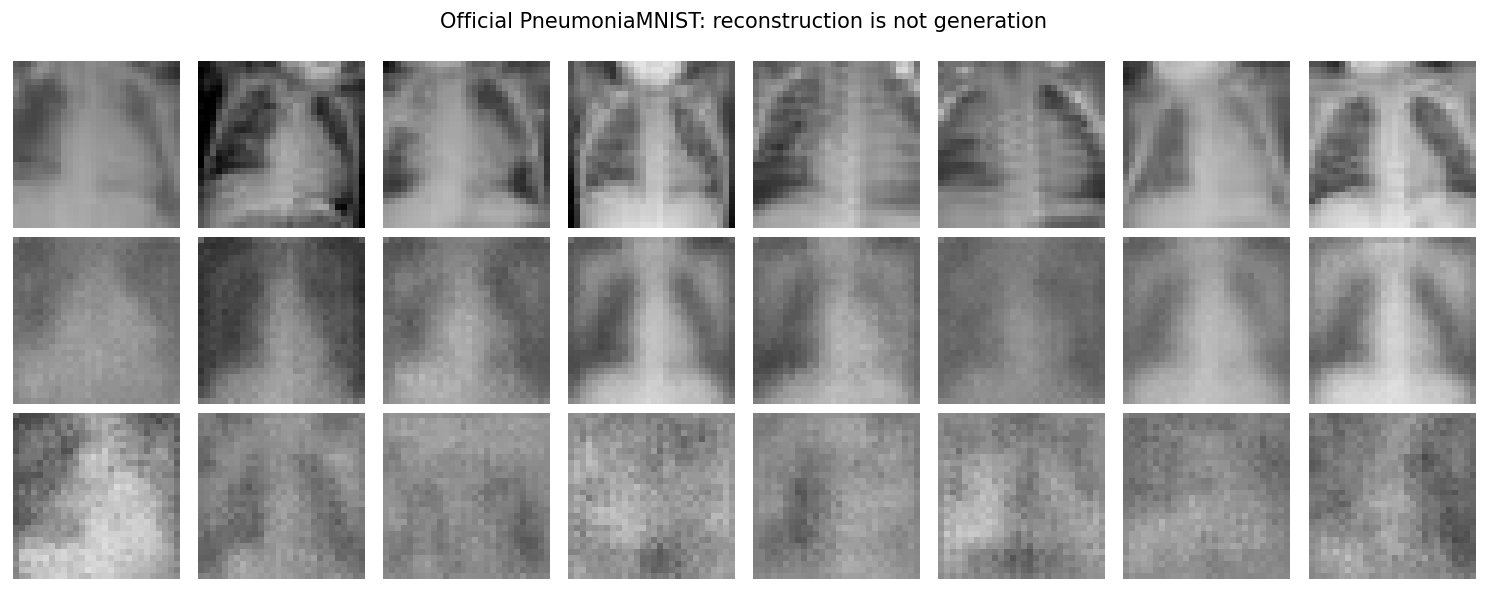

In [16]:
# Compare validation reconstructions (conditioned on real inputs) with samples
# from the prior (not tied to an input image). These are different operations.
image_model.eval()
with torch.no_grad():
    originals = image_val_tensor[:8].to(image_device)
    reconstructions, _, _ = image_model(originals)
    prior_samples = image_model.decode(torch.randn(8, image_model.latent_dim, device=image_device))

# Keep the row order fixed so inputs, reconstructions, and unrelated prior
# samples are not described as three versions of one patient.
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
rows = [originals.cpu(), reconstructions.cpu(), prior_samples.cpu()]
row_labels = ["Validation input", "Reconstruction", "Prior sample"]
for row_index, (images, row_label) in enumerate(zip(rows, row_labels)):
    for column_index in range(8):
        axes[row_index, column_index].imshow(images[column_index, 0], cmap="gray", vmin=0, vmax=1)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle("Official PneumoniaMNIST: reconstruction is not generation")
plt.tight_layout()
plt.show()


**How to read the grid.** Reconstructions begin with validation images; prior samples begin with random latent vectors. Blurring is common in small VAEs. Visual plausibility to a non-expert is not a fidelity evaluation. Meaningful assessment would need radiology expertise, feature/diversity measures suited to the domain, duplicate and privacy analysis, label/pathology preservation, subgroup and acquisition-stratum analysis, and an evaluation tied to the proposed use.


## 16. Responsible release is a governance decision

Before any row-level synthetic release or model-assisted augmentation, document:

1. the intended recipient, use, access environment, and prohibited uses;
2. legal authority, consent/ethics basis, privacy review, security controls, and retention;
3. source population, sampling, exclusions, label construction, and known biases;
4. generator architecture, preprocessing, conditions, hyperparameters, seeds, and software versions;
5. fidelity tests covering marginals, dependencies, tails, rare groups, and longitudinal logic relevant to the use;
6. utility tests performed on untouched source data for each claimed downstream task;
7. a threat model and privacy evaluation, including attacks or formal privacy mechanisms appropriate to the release;
8. human review of implausible, stigmatizing, or harmful outputs;
9. controls against re-identification, unsupported linkage, and model extraction; and
10. versioning, incident response, withdrawal, and re-evaluation after changes.

A restricted secure environment, aggregate release, or non-person-level simulator may be safer and more useful than distributing generated microdata. Synthetic generation should be compared with those alternatives rather than assumed to be the default.


## 17. What this notebook demonstrated—and did not establish

We progressed from a weak independent-marginal generator to a resampling privacy anti-baseline, a conditional Gaussian mixture, and a conditional VAE. The shared scorecard showed why a model can look strong on one dimension and weak on another. The intended outcome is not a perfectly ordered leaderboard: simpler models can outperform neural models on small tabular data, while a high-fidelity resampler can be unacceptable for sharing because it copies training rows.

The tabular source and every tabular result are simulated. The work therefore does **not** show that these methods preserve real disease patterns, protect patients, improve a clinical model, or satisfy a legal/privacy standard. The optional PneumoniaMNIST VAE similarly demonstrates architecture and tensor flow only. Real claims require use-specific source data, domain-led evaluation, privacy threat modelling, governance, and prospective evidence.


## Optional exercises

1. **Conditional marginals:** Modify the independent generator to sample each feature within label strata. Which utility and correlation metrics improve, and what remains broken?
2. **Component sensitivity:** Fit one, two, and five GMM components using the source-validation likelihood only. Compare holdout fidelity without selecting on holdout results.
3. **Latent dimension:** Compare CVAE latent dimensions 2, 4, and 12 across seeds. Does lower validation loss reliably imply better TSTR utility?
4. **Tail audit:** Add a rare high-lactate subgroup to the source. Evaluate coverage and nearest-neighbour behaviour separately for that subgroup.
5. **Threat model:** Write a concrete membership-inference adversary and identify what access and auxiliary information the attack assumes.
6. **Release alternative:** Design a schema-valid non-person simulator for pipeline testing and compare its privacy/utility requirements with microdata generation.


## References and further reading

1. Kingma DP, Welling M. [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114). *International Conference on Learning Representations*. 2014.
2. Sohn K, Lee H, Yan X. [Learning Structured Output Representation using Deep Conditional Generative Models](https://proceedings.neurips.cc/paper/2015/hash/8d55a249e6baa5c06772297520da2051-Abstract.html). *NeurIPS*. 2015.
3. Goodfellow I, Pouget-Abadie J, Mirza M, et al. [Generative Adversarial Nets](https://proceedings.neurips.cc/paper/2014/hash/f033ed80deb0234979a61f95710dbe25-Abstract.html). *NeurIPS*. 2014.
4. Ho J, Jain A, Abbeel P. [Denoising Diffusion Probabilistic Models](https://proceedings.neurips.cc/paper/2020/hash/4c5bcfec8584af0d967f1ab10179ca4b-Abstract.html). *NeurIPS*. 2020.
5. Xu L, Skoularidou M, Cuesta-Infante A, Veeramachaneni K. [Modeling tabular data using conditional GAN](https://proceedings.neurips.cc/paper/2019/hash/254ed7d2de3b23ab10936522dd547b78-Abstract.html). *NeurIPS*. 2019.
6. Choi E, Biswal S, Malin B, Duke J, Stewart WF, Sun J. [Generating multi-label discrete patient records using generative adversarial networks](https://doi.org/10.48550/arXiv.1703.06490). *Machine Learning for Healthcare*. 2017.
7. Dwork C, Roth A. [The Algorithmic Foundations of Differential Privacy](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf). *Foundations and Trends in Theoretical Computer Science*. 2014;9:211–407.
8. Stadler T, Oprisanu B, Troncoso C. [Synthetic data—anonymisation groundhog day](https://doi.org/10.48550/arXiv.2011.07018). *USENIX Security Symposium*. 2022.
9. Platzer M, Reutterer T. [Holdout-based empirical assessment of mixed-type synthetic data](https://doi.org/10.3389/fdata.2021.679939). *Frontiers in Big Data*. 2021;4:679939.
10. Yang J, Shi R, Wei D, et al. [MedMNIST v2: a large-scale lightweight benchmark for 2D and 3D biomedical image classification](https://doi.org/10.1038/s41597-022-01721-8). *Scientific Data*. 2023;10:41.
11. Haug CJ, Drazen JM. [Artificial intelligence and machine learning in clinical medicine, 2023](https://doi.org/10.1056/NEJMra2302038). *New England Journal of Medicine*. 2023;388:1201–1208.
